# Data Science Project 
## Liza Schlachtovszky 
For our analysis, we will be working with a dataframe containing information about alchol, tobacco consumption, risk factors for health and other measures describing our relevant topics.

## 1. Data Preparation

### 1.1. Loading libraries and data

In [676]:
# Importing our Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from sklearn import datasets
from statsmodels.stats.multitest import fdrcorrection as fdr

# Changing the settings for the columns
pd.set_option('display.max_columns', 100)

In [677]:
# loading the dataset 
df = pd.read_csv('data/alc_tob.csv')
df.head()
df_og = df.copy()

In [678]:
df.shape, df.columns

((33533, 28),
 Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
        'Reference area', 'FREQ', 'Frequency of observation', 'MEASURE',
        'Measure', 'AGE', 'Age', 'SEX', 'Sex', 'UNIT_MEASURE',
        'Unit of measure', 'METHODOLOGY', 'Measurement method', 'TIME_PERIOD',
        'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS',
        'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS',
        'Decimals'],
       dtype='object'))

In [679]:
df.isna().sum()

STRUCTURE                       0
STRUCTURE_ID                    0
STRUCTURE_NAME                  0
ACTION                          0
REF_AREA                        0
Reference area                  0
FREQ                            0
Frequency of observation        0
MEASURE                         0
Measure                         0
AGE                             0
Age                             0
SEX                             0
Sex                             0
UNIT_MEASURE                    0
Unit of measure                 0
METHODOLOGY                     0
Measurement method              0
TIME_PERIOD                     0
Time period                 33533
OBS_VALUE                       0
Observation value           33533
OBS_STATUS                      0
Observation status              0
UNIT_MULT                       0
Unit multiplier                 0
DECIMALS                    33533
Decimals                    33533
dtype: int64

### 1.2. Duplciate Analysis

In [680]:
# the measures in the dataset
df['Measure'].unique()

array(['Fat supply', 'Calories supply',
       'Share of population consuming vegetables daily',
       'Share of population consuming fruits daily',
       'Share of population who are daily smokers', 'Tobacco consumption',
       'Share of population who are overweight',
       'Share of population who are obese',
       'Share of population who are overweight or obese',
       'Vegetables supply', 'Fruits supply', 'Sugar supply',
       'Protein supply',
       'Share of population who are regular vaping product users',
       'Alcohol consumption'], dtype=object)

In [681]:
# Understanding the values within each column
for column in df.columns:
    print(column, df[column].unique())

STRUCTURE ['DATAFLOW']
STRUCTURE_ID ['OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0)']
STRUCTURE_NAME ['Risk factors for health']
ACTION ['I']
REF_AREA ['USA' 'ISL' 'TUR' 'CZE' 'DEU' 'PRT' 'ISR' 'SVK' 'HUN' 'GRC' 'COL' 'LVA'
 'CRI' 'CHL' 'SVN' 'PER' 'BGR' 'HRV' 'ITA' 'AUS' 'GBR' 'KOR' 'POL' 'FIN'
 'SWE' 'ESP' 'LTU' 'MEX' 'IDN' 'RUS' 'ROU' 'ARG' 'LUX' 'NLD' 'CAN' 'BEL'
 'NOR' 'DNK' 'CHN' 'IND' 'BRA' 'CHE' 'JPN' 'FRA' 'IRL' 'EST' 'AUT' 'NZL'
 'ZAF']
Reference area ['United States' 'Iceland' 'Türkiye' 'Czechia' 'Germany' 'Portugal'
 'Israel' 'Slovak Republic' 'Hungary' 'Greece' 'Colombia' 'Latvia'
 'Costa Rica' 'Chile' 'Slovenia' 'Peru' 'Bulgaria' 'Croatia' 'Italy'
 'Australia' 'United Kingdom' 'Korea' 'Poland' 'Finland' 'Sweden' 'Spain'
 'Lithuania' 'Mexico' 'Indonesia' 'Russia' 'Romania' 'Argentina'
 'Luxembourg' 'Netherlands' 'Canada' 'Belgium' 'Norway' 'Denmark'
 'China (People’s Republic of)' 'India' 'Brazil' 'Switzerland' 'Japan'
 'France' 'Ireland' 'Estonia' 'Austria' 'New Zealand

We expect each country to have one data point for each measure (with specified age group and sex) per year.

We will check if the data fits our expectations 

In [682]:
index_cols = ['Reference area','TIME_PERIOD','MEASURE','SEX','AGE']
df[df.duplicated(index_cols, keep=False)].sort_values(index_cols)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,AGE,Age,SEX,Sex,UNIT_MEASURE,Unit of measure,METHODOLOGY,Measurement method,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
992,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,AUS,Australia,A,Annual,SP_OBS,Share of population who are obese,_T,Total,F,Female,PT_POP,Percentage of population,MSRD,Measured,1995,NaN,19.5,NaN,A,Normal value,0,Units,NaN,NaN
1791,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,AUS,Australia,A,Annual,SP_OBS,Share of population who are obese,_T,Total,F,Female,PT_POP,Percentage of population,SR,Self-reporting,1995,NaN,10.3,NaN,A,Normal value,0,Units,NaN,NaN
7303,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,AUS,Australia,A,Annual,SP_OBS,Share of population who are obese,_T,Total,M,Male,PT_POP,Percentage of population,MSRD,Measured,1995,NaN,20.0,NaN,A,Normal value,0,Units,NaN,NaN
9560,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,AUS,Australia,A,Annual,SP_OBS,Share of population who are obese,_T,Total,M,Male,PT_POP,Percentage of population,SR,Self-reporting,1995,NaN,10.5,NaN,A,Normal value,0,Units,NaN,NaN
26449,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,AUS,Australia,A,Annual,SP_OBS,Share of population who are obese,_T,Total,_T,Total,PT_POP,Percentage of population,SR,Self-reporting,1995,NaN,10.4,NaN,A,Normal value,0,Units,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31308,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,USA,United States,A,Annual,SP_OVRGHT_OBS,Share of population who are overweight or obese,_T,Total,F,Female,PT_POP,Percentage of population,SR,Self-reporting,2018,NaN,60.3,NaN,A,Normal value,0,Units,NaN,NaN
2362,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,USA,United States,A,Annual,SP_OVRGHT_OBS,Share of population who are overweight or obese,_T,Total,M,Male,PT_POP,Percentage of population,MSRD,Measured,2018,NaN,77.3,NaN,A,Normal value,0,Units,NaN,NaN
6949,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,USA,United States,A,Annual,SP_OVRGHT_OBS,Share of population who are overweight or obese,_T,Total,M,Male,PT_POP,Percentage of population,SR,Self-reporting,2018,NaN,72.3,NaN,A,Normal value,0,Units,NaN,NaN
12970,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),Risk factors for health,I,USA,United States,A,Annual,SP_OVRGHT_OBS,Share of population who are overweight or obese,_T,Total,_T,Total,PT_POP,Percentage of population,MSRD,Measured,2018,NaN,73.1,NaN,A,Normal value,0,Units,NaN,NaN


Unfortunately, the data has multiple 'duplicates'. 

In [683]:
index_cols = ['Reference area','TIME_PERIOD','MEASURE','SEX','AGE', 'METHODOLOGY']
df[df.duplicated(index_cols, keep=False)].sort_values(index_cols)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,AGE,Age,SEX,Sex,UNIT_MEASURE,Unit of measure,METHODOLOGY,Measurement method,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals


Now we can see, that the dataset has unique data points for each *'Reference area', 'TIME_PERIOD', 'MEASURE', 'SEX', 'AGE', 'METHODOLOGY'* combination. 
Meaning each row is unique for a combination of a country, a year, a measure (with age group and sex specified) AND a methodology.

### 1.3. Updating Column Names

In [684]:
# We select the variables we are interested in
old_cols = ['Reference area',
            'TIME_PERIOD',
            'MEASURE',
            'Measure',
            'SEX',
            'AGE', 
            'OBS_VALUE',
            'METHODOLOGY',
            'Unit of measure']
df = df[old_cols]
df.head()

,Reference area,TIME_PERIOD,MEASURE,Measure,SEX,AGE,OBS_VALUE,METHODOLOGY,Unit of measure
0,United States,1961,FTS,Fat supply,_T,_T,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,_T,_T,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,_T,_T,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,_T,_T,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,_T,_T,113.0,_Z,Grammes per person per day


In [685]:
new_cols = ['country',
            'year',
            'MSR',
            'measure',
            'sex',
            'age',
            'value',
            'method',
            'units']

rename_dict = dict(zip(old_cols, new_cols))
df.rename(columns=rename_dict, inplace=True)

df.head()

,country,year,MSR,measure,sex,age,value,method,units
0,United States,1961,FTS,Fat supply,_T,_T,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,_T,_T,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,_T,_T,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,_T,_T,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,_T,_T,113.0,_Z,Grammes per person per day


In [686]:
old_cat = ['Fat supply', 'Calories supply',
       'Share of population consuming vegetables daily',
       'Share of population consuming fruits daily',
       'Share of population who are daily smokers', 'Tobacco consumption',
       'Share of population who are overweight',
       'Share of population who are obese',
       'Share of population who are overweight or obese',
       'Vegetables supply', 'Fruits supply', 'Sugar supply',
       'Protein supply',
       'Share of population who are regular vaping product users',
       'Alcohol consumption']
new_cat = ['Fat supply', 'Calories supply',
       'Daily vegetables',
       'Daily fruits',
       'Daily smokers', 'Tobacco consumption',
       'Overweight',
       'Obese',
       'Overweight or obese',
       'Vegetables supply', 'Fruits supply', 'Sugar supply',
       'Protein supply',
       'Regular vaping product users',
       'Alcohol consumption']

The categories referring to the supplies of a country are describing the average of that item availabile for each individual.

In [687]:
# Define a dictionary with old and new values
rename_dict = dict(zip(old_cat,new_cat))

# Replace values
df['measure'] = df['measure'].replace(rename_dict)
df.head()

,country,year,MSR,measure,sex,age,value,method,units
0,United States,1961,FTS,Fat supply,_T,_T,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,_T,_T,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,_T,_T,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,_T,_T,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,_T,_T,113.0,_Z,Grammes per person per day


---

### 1.4. Total Dataframe

In [688]:
# A dataset only the total age group, and both sexes
df_tot = df[(df['age']=='_T') & (df['sex']=='_T')]
df_tot = df_tot.drop(columns=['age','sex'])
df_tot.head()

,country,year,MSR,measure,value,method,units
0,United States,1961,FTS,Fat supply,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,113.0,_Z,Grammes per person per day


In [689]:
df['measure'].unique(), df_tot['measure'].unique()

(array(['Fat supply', 'Calories supply', 'Daily vegetables',
        'Daily fruits', 'Daily smokers', 'Tobacco consumption',
        'Overweight', 'Obese', 'Overweight or obese', 'Vegetables supply',
        'Fruits supply', 'Sugar supply', 'Protein supply',
        'Regular vaping product users', 'Alcohol consumption'],
       dtype=object),
 array(['Fat supply', 'Calories supply', 'Tobacco consumption',
        'Overweight or obese', 'Vegetables supply', 'Fruits supply',
        'Sugar supply', 'Protein supply', 'Obese', 'Overweight'],
       dtype=object))

As we can see we lost quite a few measures. We will look into this.

In [690]:
lost_meas = list()
for meas in df['measure'].unique():
    if meas not in df_tot['measure'].unique():
        lost_meas.append(meas)
lost_meas

['Daily vegetables',
 'Daily fruits',
 'Daily smokers',
 'Regular vaping product users',
 'Alcohol consumption']

In [691]:
# Checking what values are missing for the measures
for meas in lost_meas:
    for col in ['sex', 'age']:
        if len(df[(df['measure']==meas) & (df[col]=='_T')])==0:
            print(col,meas)

age Daily vegetables
age Daily fruits
age Daily smokers
age Regular vaping product users
age Alcohol consumption


Based on this, we can see that the data is missing for all ages for all five measures we were interested in. 

In [692]:
df['age'].unique()

array(['_T', 'Y_GE15', 'Y15T24'], dtype=object)

Unfortunately, since comparing these values to values on people of all ages, we will be keeping the measures describing people of ages 15 years or over. 

In [693]:
# Replace values
for meas in lost_meas:
    df.loc[df['measure']==meas,'age'] = df.loc[df['measure']==meas,'age'].replace('Y_GE15', '_T')
df.head()

,country,year,MSR,measure,sex,age,value,method,units
0,United States,1961,FTS,Fat supply,_T,_T,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,_T,_T,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,_T,_T,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,_T,_T,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,_T,_T,113.0,_Z,Grammes per person per day


In [694]:
# A dataset only the total age group, and both sexes
df_tot = df[(df['age']=='_T') & (df['sex']=='_T')]
df_tot = df_tot.drop(columns=['age','sex'])
df_tot.head()

,country,year,MSR,measure,value,method,units
0,United States,1961,FTS,Fat supply,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,113.0,_Z,Grammes per person per day


In [695]:
len(df['measure'].unique()), len(df_tot['measure'].unique())

(15, 15)

As we can see above, now we have all the measures in the total dataset. Now we can proceed.

In [696]:
# Checking for duplicates
df_tot.duplicated(['country','year','MSR']).any()

True

In [697]:
# Trying to see where (if) the duplicates defer in their values 
df_tot[df_tot.duplicated(['country','year','MSR'], keep=False)].sort_values(['country','year','MSR'])

,country,year,MSR,measure,value,method,units
26449,Australia,1995,SP_OBS,Obese,10.4,SR,Percentage of population
28816,Australia,1995,SP_OBS,Obese,19.8,MSRD,Percentage of population
12926,Australia,1995,SP_OVRGHT,Overweight,39.4,MSRD,Percentage of population
27878,Australia,1995,SP_OVRGHT,Overweight,28.3,SR,Percentage of population
14992,Australia,1995,SP_OVRGHT_OBS,Overweight or obese,38.7,SR,Percentage of population
...,...,...,...,...,...,...,...
23992,United States,2018,SP_OBS,Obese,42.8,MSRD,Percentage of population
17785,United States,2018,SP_OVRGHT,Overweight,34.6,SR,Percentage of population
31326,United States,2018,SP_OVRGHT,Overweight,30.3,MSRD,Percentage of population
12970,United States,2018,SP_OVRGHT_OBS,Overweight or obese,73.1,MSRD,Percentage of population


We can see that the duplicates differ in the methodology used to obtain the data. We will average the values for these duplicates.

In [698]:
# Group by all relevant columns except 'method' and compute the mean
df_tot = df_tot.groupby(['country', 'year', 'MSR', 'measure', 'units'], as_index=False)['value'].mean()

df_tot.head() 

,country,year,MSR,measure,units,value
0,Argentina,1961,AC,Alcohol consumption,Litres per person,16.4
1,Argentina,1962,AC,Alcohol consumption,Litres per person,16.7
2,Argentina,1963,AC,Alcohol consumption,Litres per person,17.6
3,Argentina,1964,AC,Alcohol consumption,Litres per person,17.8
4,Argentina,1965,AC,Alcohol consumption,Litres per person,17.8


In [699]:
# Understanding the values within each column
for column in df_tot.columns:
    print(column, df_tot[column].unique())

country ['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'Chile' 'China (People’s Republic of)' 'Colombia' 'Costa Rica' 'Croatia'
 'Czechia' 'Denmark' 'Estonia' 'Finland' 'France' 'Germany' 'Greece'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Ireland' 'Israel' 'Italy'
 'Japan' 'Korea' 'Latvia' 'Lithuania' 'Luxembourg' 'Mexico' 'Netherlands'
 'New Zealand' 'Norway' 'Peru' 'Poland' 'Portugal' 'Romania' 'Russia'
 'Slovak Republic' 'Slovenia' 'South Africa' 'Spain' 'Sweden'
 'Switzerland' 'Türkiye' 'United Kingdom' 'United States']
year [1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 1960 2022 2023]
MSR ['AC' 'SP_OBS' 'SP_DS' 'CLS' 'FRS' 'FTS' 'PRS' 'SGS' 'VGS' 'TBC'
 'SP_OVRGHT' 'SP_OVRGHT_OBS' 'SP_CFRD' 'SP

Alcohol consumption (1995, 49)
Obese (2014, 41)
Daily smokers (2019, 40)
Calories supply (2010, 49)
Fruits supply (2010, 49)
Fat supply (2010, 49)
Protein supply (2010, 49)
Sugar supply (2010, 49)
Vegetables supply (2010, 49)
Tobacco consumption (2014, 29)
Overweight (2014, 33)
Overweight or obese (2014, 33)
Daily fruits (2014, 32)
Daily vegetables (2014, 32)
Regular vaping product users (2019, 27)


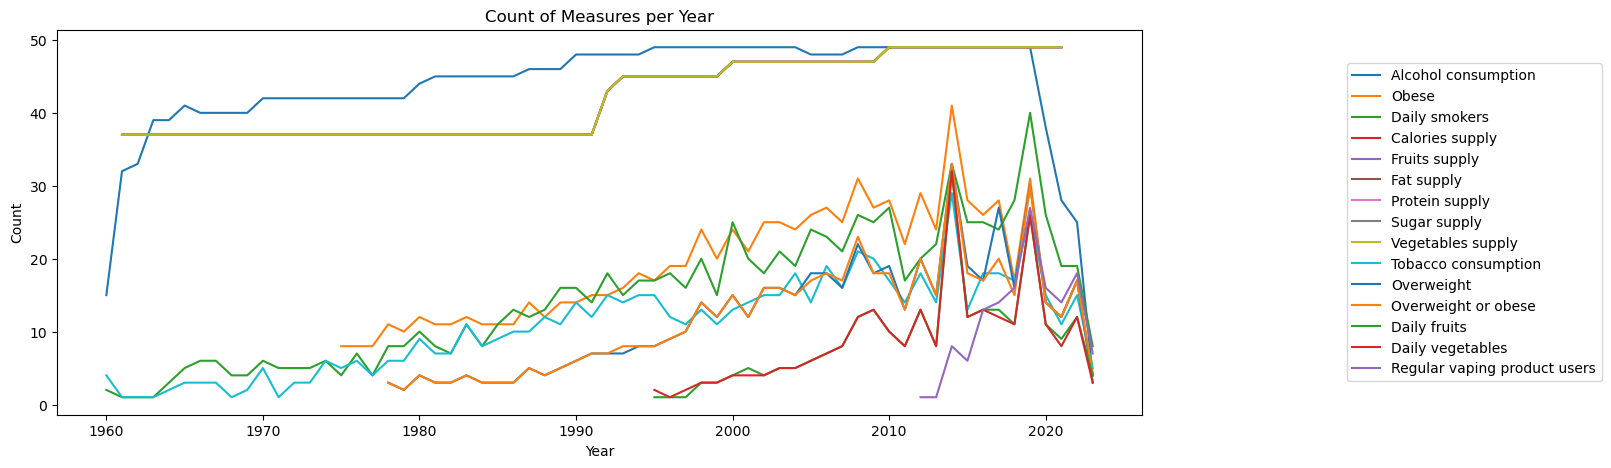

In [700]:
plt.figure(figsize=(14, 5))
for category in df_tot['measure'].unique():
    count = df_tot[df_tot['measure']==category]['year'].value_counts().sort_index()
    print(category, max(count.items(), key=lambda x: x[1]))
    plt.plot(count.index, count.values, label=category)

plt.xticks(range(1960, 2024, 10))  
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Count of Measures per Year')
plt.legend(loc='right',bbox_to_anchor=(1.43, 0.5))

plt.show()

it seems that 2014 and 2019 have the most data points

In [701]:
ac_df = df_tot[df_tot['MSR']=='AC']
ac_df.head()

,country,year,MSR,measure,units,value
0,Argentina,1961,AC,Alcohol consumption,Litres per person,16.4
1,Argentina,1962,AC,Alcohol consumption,Litres per person,16.7
2,Argentina,1963,AC,Alcohol consumption,Litres per person,17.6
3,Argentina,1964,AC,Alcohol consumption,Litres per person,17.8
4,Argentina,1965,AC,Alcohol consumption,Litres per person,17.8


In [702]:
ds_df = df_tot[df_tot['MSR']=='SP_DS']
ds_df.head()

,country,year,MSR,measure,units,value
65,Argentina,2000,SP_DS,Daily smokers,Percentage of population,33.5
76,Argentina,2005,SP_DS,Daily smokers,Percentage of population,30.8
92,Argentina,2010,SP_DS,Daily smokers,Percentage of population,28.3
133,Argentina,2015,SP_DS,Daily smokers,Percentage of population,26.0
157,Argentina,2018,SP_DS,Daily smokers,Percentage of population,24.7


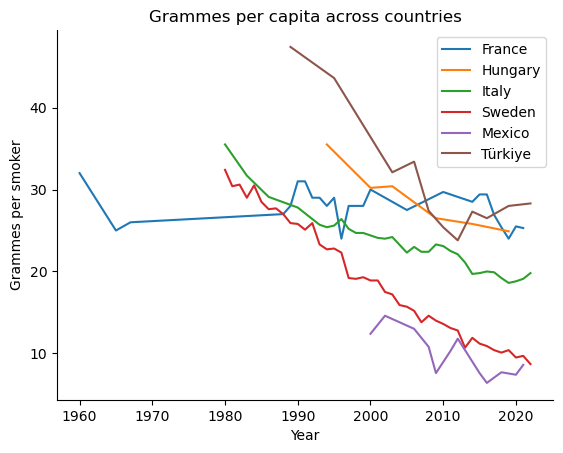

In [703]:
for country, color in zip(['France', 'Hungary', 'Italy', 'Sweden', 'Mexico', 'Türkiye'],['maroon', 'navy', 'rosybrown', 'darkgreen', 'darkorange', 'olive']):
    country_df = ds_df[ds_df['country']==country]
    plt.plot(country_df['year'], country_df['value'], label=country)

plt.xticks(range(1960, 2024, 10))  
plt.xlabel('Year')
plt.ylabel('Grammes per smoker')
plt.title('Grammes per capita across countries')
plt.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### 1.5. Sexes - Smoking behavior 

/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/1331945212.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rel_df = df[df['country']==country][df['MSR']=='SP_DS']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/1331945212.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  m_15pl = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y_GE15']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/1331945212.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  f_15pl = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y_GE15']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/1331945212.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  m_15t24 = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y15T24']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/1331945212.py:7: UserWarning: Boolean Series key will b

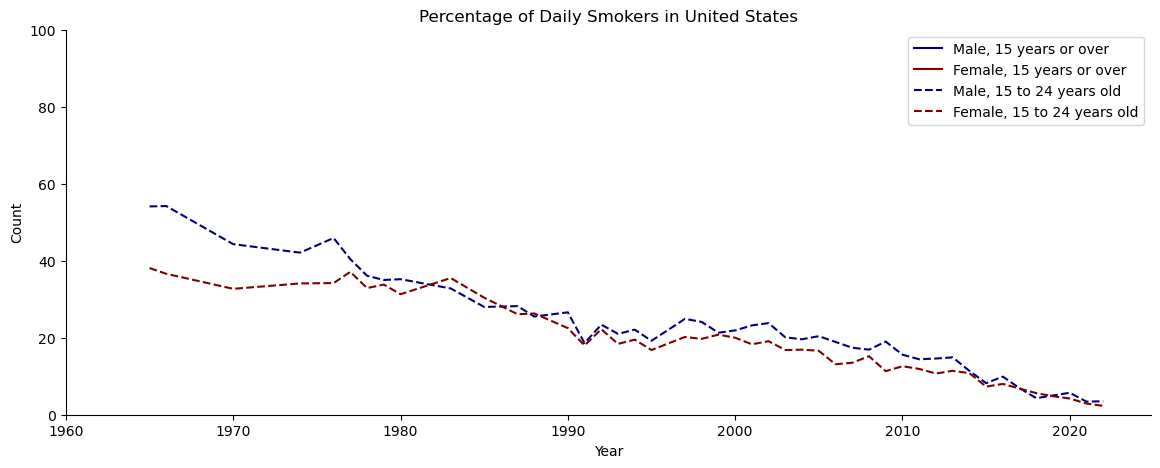

In [704]:
# Create variables for the data of interest
country = 'United States'
rel_df = df[df['country']==country][df['MSR']=='SP_DS']
m_15pl = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y_GE15']
f_15pl = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y_GE15']
m_15t24 = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y15T24']
f_15t24 = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y15T24']

plt.figure(figsize=(14, 5))
plt.plot(m_15pl['year'], m_15pl['value'], color='navy', label='Male, 15 years or over')
plt.plot(f_15pl['year'], f_15pl['value'], color='maroon', label='Female, 15 years or over')
plt.plot(m_15t24['year'], m_15t24['value'], color='navy', label='Male, 15 to 24 years old', linestyle='dashed')
plt.plot(f_15t24['year'], f_15t24['value'], color='maroon', label='Female, 15 to 24 years old', linestyle='dashed')

plt.xticks(range(1960, 2024, 10))  
plt.xlabel('Year')
plt.ylabel('Count')
plt.ylim(0,100)
plt.title('Percentage of Daily Smokers in '+country)
plt.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/3589257219.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  m_15pl = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y_GE15']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/3589257219.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  f_15pl = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y_GE15']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/3589257219.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  m_15t24 = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y15T24']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/3589257219.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  f_15t24 = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y15T24']
/var/folders/z7/mlmp6wrd4bj111ppbldnmj540000gn/T/ipykernel_92718/3589257219.py:11: UserWarning: Boolean Series

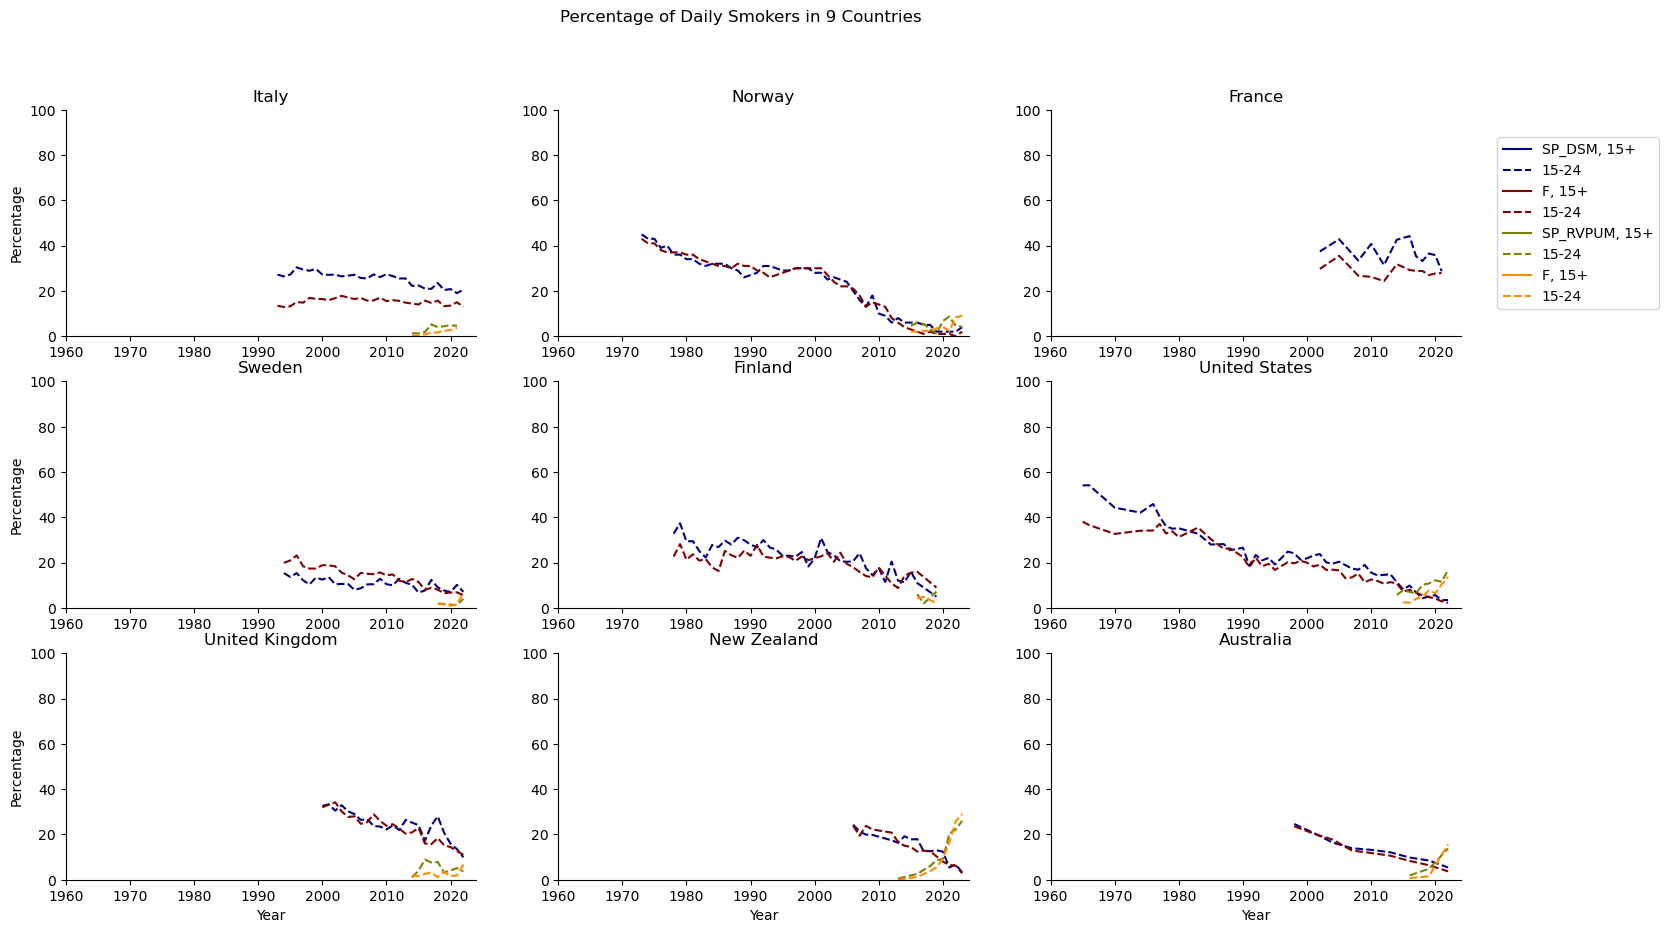

In [705]:
# Create variables for the data of interest
fig, ax = plt.subplots(3, 3, figsize=(18, 10))
plt.suptitle('Percentage of Daily Smokers in 9 Countries')
for i,country in enumerate(['Italy','Norway','France','Sweden','Finland','United States','United Kingdom', 'New Zealand', 'Australia']):
    for measure,colors in zip(['SP_DS', 'SP_RVPU'],[['navy','maroon'],['olive','darkorange']]):
        rel_df = df[
            (df['country']==country) &
            (df['MSR']==measure)
        ]
        # Specify for each category of interest
        m_15pl = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y_GE15']
        f_15pl = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y_GE15']
        m_15t24 = rel_df[rel_df['sex']=='M'][rel_df['age']=='Y15T24']
        f_15t24 = rel_df[rel_df['sex']=='F'][rel_df['age']=='Y15T24']

        row, col = divmod(i, 3)             # specify the position of the subplot
        ax[row,col].plot(m_15pl['year'], m_15pl['value'], color=colors[0], label=measure+'M, 15+')
        ax[row,col].plot(m_15t24['year'], m_15t24['value'], color=colors[0], label='15-24', linestyle='dashed')
        ax[row,col].plot(f_15pl['year'], f_15pl['value'], color=colors[1], label='F, 15+')
        ax[row,col].plot(f_15t24['year'], f_15t24['value'], color=colors[1], label='15-24', linestyle='dashed')

        # ax[row, col].set_xticks(range(1960, 2024, 10))
        if row == 2:
            ax[row, col].set_xlabel('Year')
        if col == 0:
            ax[row, col].set_ylabel('Percentage')

        ax[row,col].set_ylim(0,100)
        ax[row,col].set_xlim(1960,2024)

        ax[row,col].set_title(country)
        if row == 0 and col == 2:
            ax[row,col].legend(loc='right',bbox_to_anchor=(1.5, 0.5))
        
        ax[row,col].spines['top'].set_visible(False)
        ax[row,col].spines['right'].set_visible(False)
plt.show()

### 1.6. Data Processing

#### Pivoting 
The dataset's structure is not ideal for correlation testing. We want each row to to include all measure for one country in one specific year. 
Therefore, we need to create a _new dataset by pivoting the old one._

In [706]:
new_df = df_tot.copy()

In [707]:
df_tot['measure'].unique()

array(['Alcohol consumption', 'Obese', 'Daily smokers', 'Calories supply',
       'Fruits supply', 'Fat supply', 'Protein supply', 'Sugar supply',
       'Vegetables supply', 'Tobacco consumption', 'Overweight',
       'Overweight or obese', 'Daily fruits', 'Daily vegetables',
       'Regular vaping product users'], dtype=object)

In [708]:
new_df = df_tot.pivot_table(
    index=["country", "year"],
    columns="measure",
    values=["value"],
    margins=False,
)
new_df.head()

value                                             \
measure        Alcohol consumption Calories supply Daily fruits Daily smokers   
country   year                                                                  
Argentina 1961                16.4             NaN          NaN           NaN   
          1962                16.7             NaN          NaN           NaN   
          1963                17.6             NaN          NaN           NaN   
          1964                17.8             NaN          NaN           NaN   
          1965                17.8             NaN          NaN           NaN   

                                                                           \
measure        Daily vegetables Fat supply Fruits supply Obese Overweight   
country   year                                                              
Argentina 1961              NaN        NaN           NaN   NaN        NaN   
          1962              NaN        NaN           NaN   NaN        NaN   
          1963              NaN        NaN           NaN   NaN        NaN   
          1964              NaN        NaN           NaN   NaN        NaN   
          1965              NaN        NaN           NaN   NaN        NaN   

                                                   \
measure        Overweight or obese Protein supply   
country   year                                      
Argentina 1961                 NaN            NaN   
          1962                 NaN            NaN   
          1963                 NaN            NaN   
          1964                 NaN            NaN   
          1965                 NaN            NaN   

                                                                              \
measure        Regular vaping product users Sugar supply Tobacco consumption   
country   year                                                                 
Argentina 1961                          NaN          NaN                 NaN   
          1962                          NaN          NaN                 NaN   
          1963                          NaN          NaN                 NaN   
          1964                          NaN          NaN                 NaN   
          1965                          NaN          NaN                 NaN   

                                  
measure        Vegetables supply  
country   year                    
Argentina 1961               NaN  
          1962               NaN  
          1963               NaN  
          1964               NaN  
          1965               NaN

In [709]:
variable_names = ['Daily smokers',
                  'Tobacco consumption',
                  'Alcohol consumption', 
                  'Calories supply',
                  'Daily fruits',
                  'Daily vegetables',
                  'Fat supply', 
                  'Fruits supply',
                  'Obese',
                  'Overweight',
                  'Overweight or obese',
                  'Protein supply',
                  'Regular vaping product users',
                  'Sugar supply',
                  'Vegetables supply']

#### Adjustments

##### 1. Removing the top level of the columns

In [710]:
new_df.columns

MultiIndex([('value',          'Alcohol consumption'),
            ('value',              'Calories supply'),
            ('value',                 'Daily fruits'),
            ('value',                'Daily smokers'),
            ('value',             'Daily vegetables'),
            ('value',                   'Fat supply'),
            ('value',                'Fruits supply'),
            ('value',                        'Obese'),
            ('value',                   'Overweight'),
            ('value',          'Overweight or obese'),
            ('value',               'Protein supply'),
            ('value', 'Regular vaping product users'),
            ('value',                 'Sugar supply'),
            ('value',          'Tobacco consumption'),
            ('value',            'Vegetables supply')],
           names=[None, 'measure'])

In [711]:
# To make our lives easier, we will remove the top level of the columns
new_df.columns = new_df.columns.droplevel(0)
new_df.head()

measure         Alcohol consumption  Calories supply  Daily fruits  \
country   year                                                       
Argentina 1961                 16.4              NaN           NaN   
          1962                 16.7              NaN           NaN   
          1963                 17.6              NaN           NaN   
          1964                 17.8              NaN           NaN   
          1965                 17.8              NaN           NaN   

measure         Daily smokers  Daily vegetables  Fat supply  Fruits supply  \
country   year                                                               
Argentina 1961            NaN               NaN         NaN            NaN   
          1962            NaN               NaN         NaN            NaN   
          1963            NaN               NaN         NaN            NaN   
          1964            NaN               NaN         NaN            NaN   
          1965            NaN               NaN         NaN            NaN   

measure         Obese  Overweight  Overweight or obese  Protein supply  \
country   year                                                           
Argentina 1961    NaN         NaN                  NaN             NaN   
          1962    NaN         NaN                  NaN             NaN   
          1963    NaN         NaN                  NaN             NaN   
          1964    NaN         NaN                  NaN             NaN   
          1965    NaN         NaN                  NaN             NaN   

measure         Regular vaping product users  Sugar supply  \
country   year                                               
Argentina 1961                           NaN           NaN   
          1962                           NaN           NaN   
          1963                           NaN           NaN   
          1964                           NaN           NaN   
          1965                           NaN           NaN   

measure         Tobacco consumption  Vegetables supply  
country   year                                          
Argentina 1961                  NaN                NaN  
          1962                  NaN                NaN  
          1963                  NaN                NaN  
          1964                  NaN                NaN  
          1965                  NaN                NaN

In [712]:
new_df.columns

Index(['Alcohol consumption', 'Calories supply', 'Daily fruits',
       'Daily smokers', 'Daily vegetables', 'Fat supply', 'Fruits supply',
       'Obese', 'Overweight', 'Overweight or obese', 'Protein supply',
       'Regular vaping product users', 'Sugar supply', 'Tobacco consumption',
       'Vegetables supply'],
      dtype='object', name='measure')

##### 2. Filling in the missing data
Before we continue, we will fill in the missing data points 

In [713]:
new_df.isna().sum()

measure
Alcohol consumption               97
Calories supply                  322
Daily fruits                    2626
Daily smokers                   1964
Daily vegetables                2627
Fat supply                       322
Fruits supply                    322
Obese                           1968
Overweight                      2334
Overweight or obese             2341
Protein supply                   322
Regular vaping product users    2744
Sugar supply                     322
Tobacco consumption             2198
Vegetables supply                322
dtype: int64

In [714]:
# Checking for missing values
for col in new_df.columns:
    print(col,'\n', new_df[col].groupby("country")\
        .apply(lambda rows: rows.isna().mean())\
        .sort_values(ascending=False).head(15))

Alcohol consumption 
 country
Croatia        0.276596
France         0.158730
Russia         0.156250
New Zealand    0.125000
Lithuania      0.096774
Greece         0.080645
Denmark        0.078125
Chile          0.065574
Luxembourg     0.063492
Belgium        0.050000
Brazil         0.049180
Bulgaria       0.049180
Israel         0.048387
Portugal       0.048387
Italy          0.048387
Name: Alcohol consumption, dtype: float64
Calories supply 
 country
Argentina          0.803279
Peru               0.803279
Luxembourg         0.650794
Belgium            0.633333
Slovak Republic    0.539683
Croatia            0.361702
Czechia            0.325581
Latvia             0.302326
Slovenia           0.285714
Estonia            0.090909
Russia             0.062500
Ireland            0.046875
Denmark            0.046875
Norway             0.046875
New Zealand        0.046875
Name: Calories supply, dtype: float64
Daily fruits 
 country
Argentina                       1.000000
China (People’s Repu

In [715]:
# Fill missing values by interpolating across years (grouped by country and measure)
new_df = new_df.apply(lambda x: x.interpolate(method='linear'))
new_df.head()

measure         Alcohol consumption  Calories supply  Daily fruits  \
country   year                                                       
Argentina 1961                 16.4              NaN           NaN   
          1962                 16.7              NaN           NaN   
          1963                 17.6              NaN           NaN   
          1964                 17.8              NaN           NaN   
          1965                 17.8              NaN           NaN   

measure         Daily smokers  Daily vegetables  Fat supply  Fruits supply  \
country   year                                                               
Argentina 1961            NaN               NaN         NaN            NaN   
          1962            NaN               NaN         NaN            NaN   
          1963            NaN               NaN         NaN            NaN   
          1964            NaN               NaN         NaN            NaN   
          1965            NaN               NaN         NaN            NaN   

measure         Obese  Overweight  Overweight or obese  Protein supply  \
country   year                                                           
Argentina 1961    NaN         NaN                  NaN             NaN   
          1962    NaN         NaN                  NaN             NaN   
          1963    NaN         NaN                  NaN             NaN   
          1964    NaN         NaN                  NaN             NaN   
          1965    NaN         NaN                  NaN             NaN   

measure         Regular vaping product users  Sugar supply  \
country   year                                               
Argentina 1961                           NaN           NaN   
          1962                           NaN           NaN   
          1963                           NaN           NaN   
          1964                           NaN           NaN   
          1965                           NaN           NaN   

measure         Tobacco consumption  Vegetables supply  
country   year                                          
Argentina 1961                  NaN                NaN  
          1962                  NaN                NaN  
          1963                  NaN                NaN  
          1964                  NaN                NaN  
          1965                  NaN                NaN

In [716]:
# we will check again to see if we have fewer missing values now
for col in new_df.columns:
    print(col,'\n', new_df[col].groupby("country")\
        .apply(lambda rows: rows.isna().mean())\
        .sort_values(ascending=False).head(15))

Alcohol consumption 
 country
Argentina      0.0
Italy          0.0
Korea          0.0
Latvia         0.0
Lithuania      0.0
Luxembourg     0.0
Mexico         0.0
Netherlands    0.0
New Zealand    0.0
Norway         0.0
Peru           0.0
Poland         0.0
Portugal       0.0
Romania        0.0
Russia         0.0
Name: Alcohol consumption, dtype: float64
Calories supply 
 country
Argentina      0.803279
Italy          0.000000
Korea          0.000000
Latvia         0.000000
Lithuania      0.000000
Luxembourg     0.000000
Mexico         0.000000
Netherlands    0.000000
New Zealand    0.000000
Norway         0.000000
Peru           0.000000
Poland         0.000000
Portugal       0.000000
Romania        0.000000
Russia         0.000000
Name: Calories supply, dtype: float64
Daily fruits 
 country
Argentina         1.000000
Australia         0.650794
United Kingdom    0.000000
Peru              0.000000
Japan             0.000000
Korea             0.000000
Latvia            0.000000
Lithuan

In [717]:
# indeed we do! However, Argentina seems to be missing a large amount of data, we will drop it
new_df=new_df.drop(index='Argentina')
new_df.head()

measure         Alcohol consumption  Calories supply  Daily fruits  \
country   year                                                       
Australia 1960                  9.3           3216.0           NaN   
          1961                  9.4           3091.0           NaN   
          1962                  9.5           3113.0           NaN   
          1963                  9.8           3169.0           NaN   
          1964                 10.1           3146.0           NaN   

measure         Daily smokers  Daily vegetables  Fat supply  Fruits supply  \
country   year                                                               
Australia 1960      30.333333               NaN       125.4          77.15   
          1961      33.500000               NaN       111.3          77.70   
          1962      36.666667               NaN       111.8          77.20   
          1963      39.833333               NaN       112.1          83.30   
          1964      43.000000               NaN       110.6          79.80   

measure             Obese  Overweight  Overweight or obese  Protein supply  \
country   year                                                               
Australia 1960  23.861538         NaN                  NaN          112.45   
          1961  23.088462         NaN                  NaN          104.90   
          1962  22.315385         NaN                  NaN          107.90   
          1963  21.542308         NaN                  NaN          109.10   
          1964  20.769231         NaN                  NaN          110.30   

measure         Regular vaping product users  Sugar supply  \
country   year                                               
Australia 1960                           NaN         47.35   
          1961                           NaN         56.20   
          1962                           NaN         54.40   
          1963                           NaN         54.80   
          1964                           NaN         56.20   

measure         Tobacco consumption  Vegetables supply  
country   year                                          
Australia 1960                  NaN               67.4  
          1961                  NaN               61.5  
          1962                  NaN               61.4  
          1963                  NaN               60.1  
          1964                 16.7               61.4

In [718]:
new_df.isna().sum()

measure
Alcohol consumption              0
Calories supply                  0
Daily fruits                    41
Daily smokers                    0
Daily vegetables                41
Fat supply                       0
Fruits supply                    0
Obese                            0
Overweight                      20
Overweight or obese             20
Protein supply                   0
Regular vaping product users    56
Sugar supply                     0
Tobacco consumption              4
Vegetables supply                0
dtype: int64

##### 3. Limiting the number of column we will be working with 

In [719]:
keep_cols = ['Alcohol consumption', 'Calories supply', 'Daily smokers', 'Fat supply',
       'Fruits supply', 'Obese', 'Protein supply', 'Sugar supply',
       'Tobacco consumption', 'Vegetables supply']
new_df=new_df[keep_cols]
new_df = new_df.iloc[:, [2, 8, 0, 1, 3, 4, 5, 6, 7, 9]]
new_df.head()

measure         Daily smokers  Tobacco consumption  Alcohol consumption  \
country   year                                                            
Australia 1960      30.333333                  NaN                  9.3   
          1961      33.500000                  NaN                  9.4   
          1962      36.666667                  NaN                  9.5   
          1963      39.833333                  NaN                  9.8   
          1964      43.000000                 16.7                 10.1   

measure         Calories supply  Fat supply  Fruits supply      Obese  \
country   year                                                          
Australia 1960           3216.0       125.4          77.15  23.861538   
          1961           3091.0       111.3          77.70  23.088462   
          1962           3113.0       111.8          77.20  22.315385   
          1963           3169.0       112.1          83.30  21.542308   
          1964           3146.0       110.6          79.80  20.769231   

measure         Protein supply  Sugar supply  Vegetables supply  
country   year                                                   
Australia 1960          112.45         47.35               67.4  
          1961          104.90         56.20               61.5  
          1962          107.90         54.40               61.4  
          1963          109.10         54.80               60.1  
          1964          110.30         56.20               61.4

## 2. Graphs 

Next, we want to explore **correlations** between the different columns in the dataset.

There are many different approaches one could take.
Do we want an image worldwide or nationwide? 
One year all countries?
One country all years?
All countries all years?
We also have a large variety of measure we could choose for our analysis. 

### 2.1. Correlation Matrices 

#### Experimenting

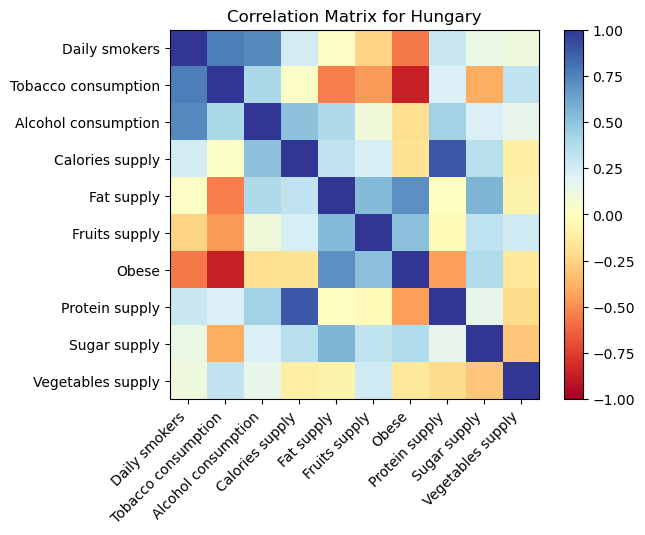

In [720]:
country='Hungary'
matrix = new_df.xs(country, level="country").corr()
# new_df[new_df['MEASURE']=='SP_DS'][df['country']=='Italy'][['OBS_VALUE','TIME_PERIOD']].corr()

# plotting correlation matrix
plt.imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

# adding colorbar
plt.colorbar()

# extracting variable names
variables = []
for i in matrix.columns:
    variables.append(i)

# Adding labels to the matrix
plt.xticks(range(len(matrix)), new_df.columns, rotation=45, ha='right')
plt.yticks(range(len(matrix)), new_df.columns)
plt.title("Correlation Matrix for "+country)

# Display the plot
plt.show()


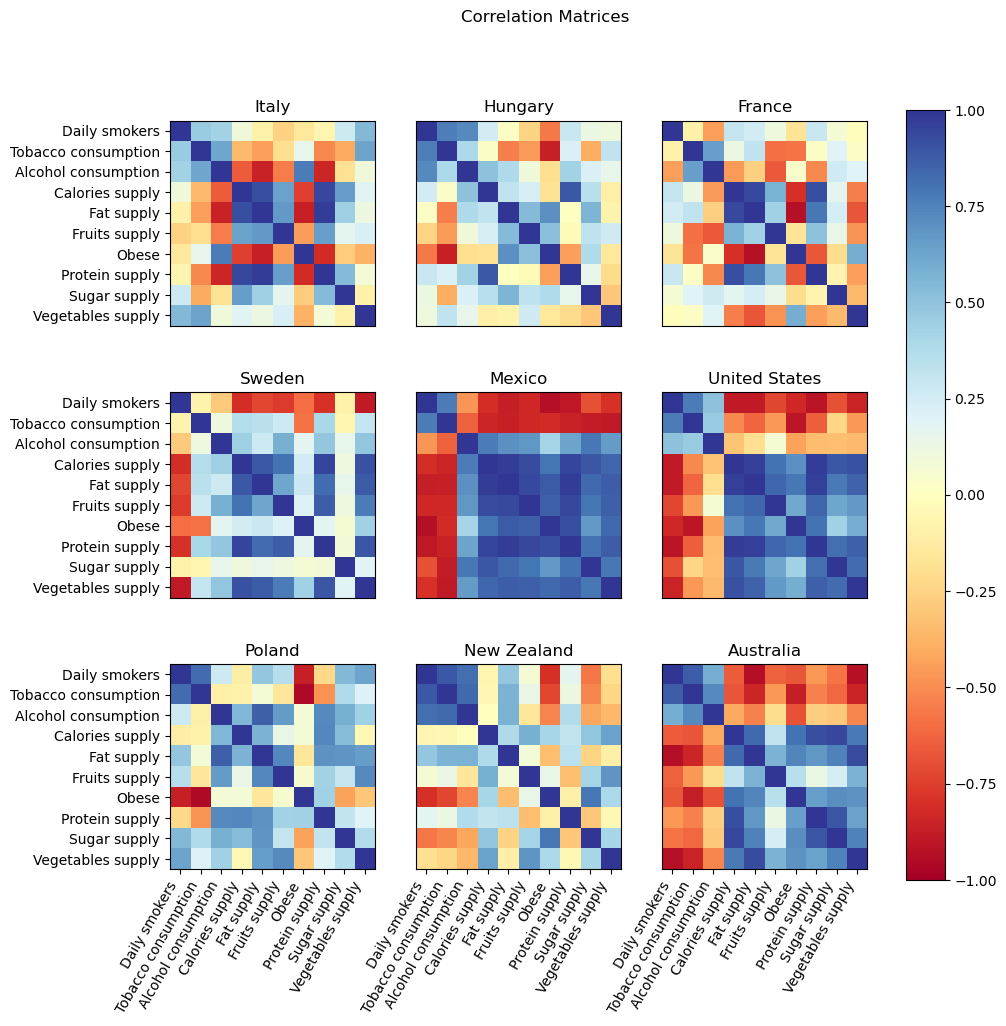

In [721]:
countries=['Italy','Hungary','France','Sweden','Mexico','United States','Poland', 'New Zealand', 'Australia']

rows,cols=3,3
fig,ax=plt.subplots(rows,cols,figsize=(10,10))
plt.suptitle("Correlation Matrices")

for i,country in enumerate(countries):
    matrix = new_df.xs(country, level="country").corr()
    row,col=divmod(i,3)
    ax[row,col].imshow(matrix, cmap='RdYlBu')
    ax[row,col].set_title(country)
    
    if row==rows-1:
        ax[row,col].set_xticks(range(len(matrix.columns)))
        ax[row,col].set_xticklabels(new_df.columns, rotation=60, ha='right')
    else:
        ax[row,col].set_xticks([])
        
    if col==0:
        ax[row,col].set_yticks(range(len(matrix.columns)))
        ax[row,col].set_yticklabels(new_df.columns)

    else:
        ax[row,col].set_yticks([])
    ax[row,col].set_title(country)
    # Plot correlation matrix with fixed color scale from -1 to 1
    im = ax[row,col].imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

# Add a single colorbar for the entire figure
fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.05)

plt.show()

#### Fewest Missing Values

In [722]:
# Creating a list of the countries with the least amount of missing values
data_na = {}

# Iterate over countries in the index
for country in new_df.index.get_level_values("country").unique():
    country_df = new_df.xs(country, level="country")  # Select data for the country
    data_na[country] = (country_df.isna().sum() / len(country_df)).mean()

# Sort by missing value percentage and extract keys
data_na = dict(sorted(data_na.items(), key=lambda item: item[1])).keys()

# Output sorted country names
data_na


dict_keys(['Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China (People’s Republic of)', 'Colombia', 'Costa Rica', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Peru', 'Poland', 'Portugal', 'Romania', 'Russia', 'Slovak Republic', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom', 'United States', 'Australia'])

In [723]:
countries=list(data_na)[:15]
countries

['Austria',
 'Belgium',
 'Brazil',
 'Bulgaria',
 'Canada',
 'Chile',
 'China (People’s Republic of)',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France']

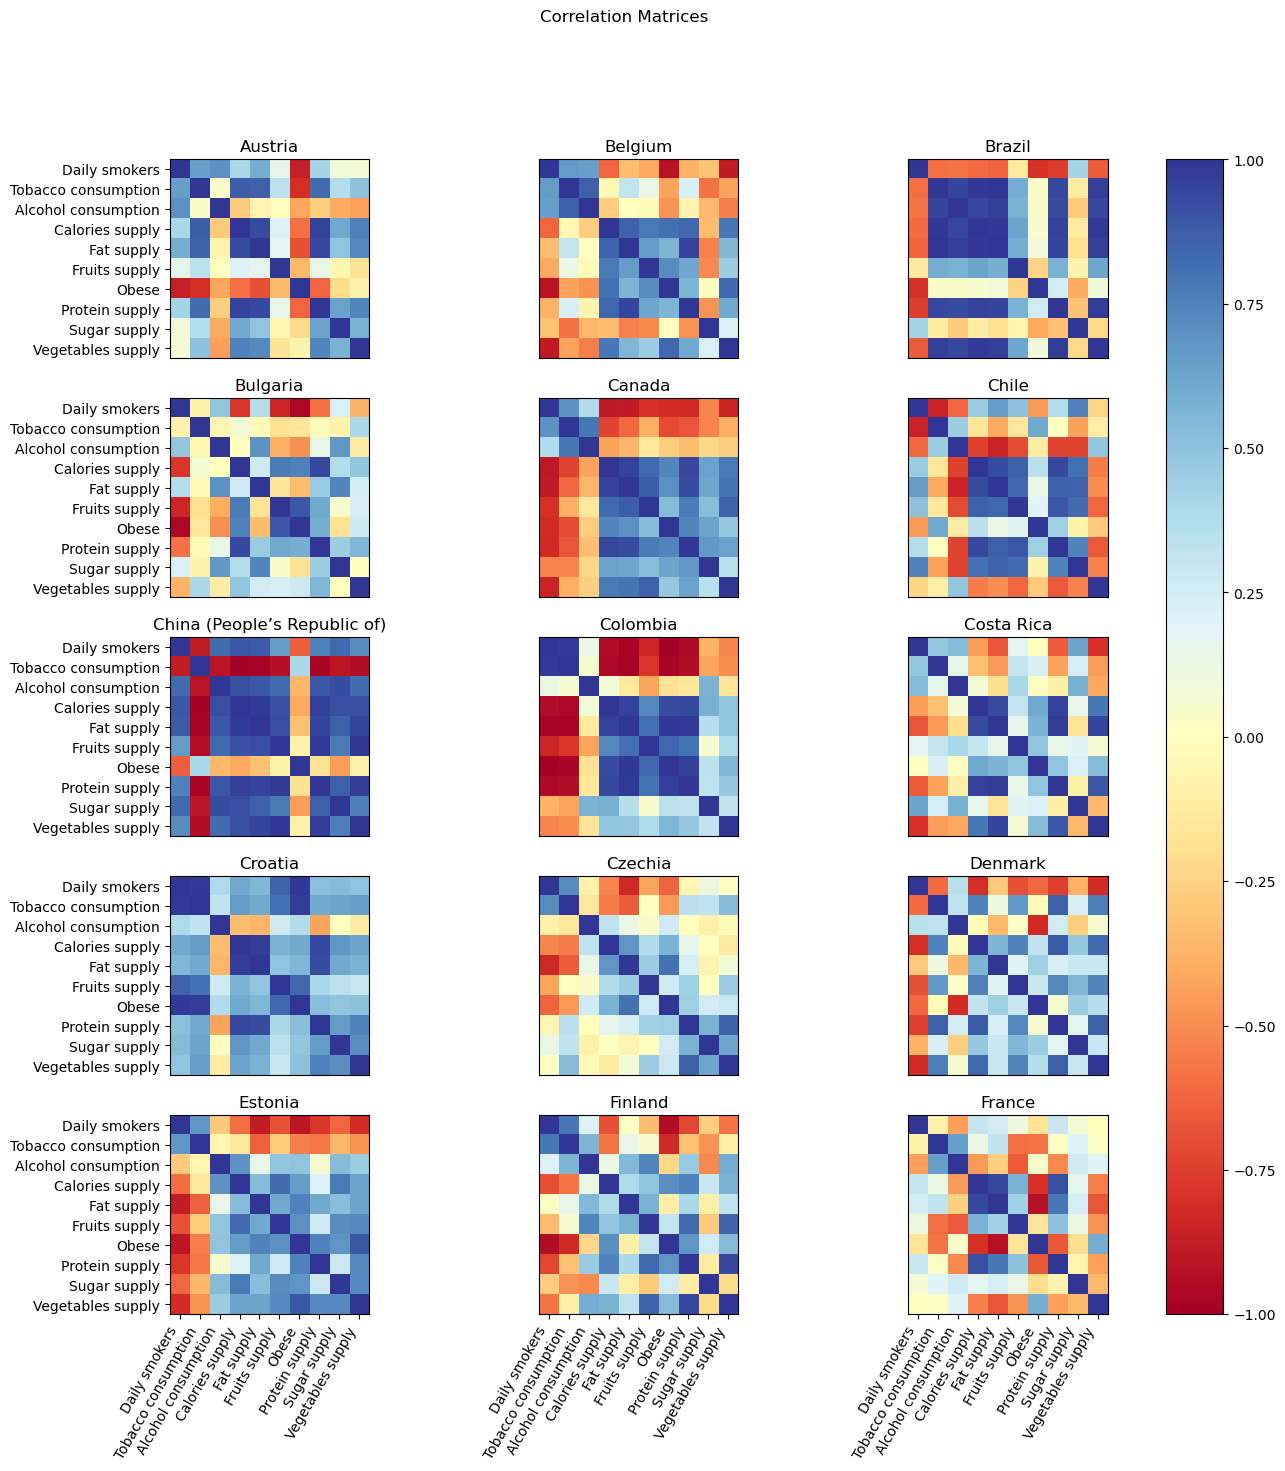

In [724]:
rows,cols=5,3
fig,ax=plt.subplots(rows,cols,figsize=(15,15))
plt.suptitle('Correlation Matrices')

# Store the last image for colorbar
im = None 

for i,country in enumerate(countries):
    matrix = new_df.xs(country, level="country").corr()
    row,col=divmod(i,cols)
    ax[row,col].imshow(matrix, cmap='RdYlBu')
    ax[row,col].set_title(country)
    
    if row==rows-1:
        ax[row,col].set_xticks(range(len(matrix.columns)))
        ax[row,col].set_xticklabels(new_df.columns, rotation=60, ha='right')
    else:
        ax[row,col].set_xticks([])
        
    if col==0:
        ax[row,col].set_yticks(range(len(matrix.columns)))
        ax[row,col].set_yticklabels(new_df.columns)

    else:
        ax[row,col].set_yticks([])
    ax[row,col].set_title(country)
    
    # Plot correlation matrix with fixed color scale from -1 to 1
    im = ax[row,col].imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

# Add a single colorbar for the entire figure
fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.05)

plt.show()


#### Highest and Lowest Percentage of _Daily smokers_.

If we want to really see what affects smoking behavior, we can make comparisons between the countries with the highest and the lowest average percentage of daily smokers.


In [725]:
# Group by country and calculate the average smoking rate
avg_ds = new_df.groupby(level="country")['Daily smokers'].mean()

# Find the highest and lowest average smoking rates
highest = avg_ds.nlargest(5)
lowest = avg_ds.nsmallest(5)

print("Highest % daily smokers", highest)
print("\nLowest % daily smokers:", lowest)


Highest % daily smokers country
Denmark        35.041406
Netherlands    34.934921
Russia         32.968709
Türkiye        32.802381
Japan          32.065423
Name: Daily smokers, dtype: float64

Lowest % daily smokers: country
Mexico        13.486885
Costa Rica    13.903801
Brazil        15.367427
India         16.000640
Croatia       16.907447
Name: Daily smokers, dtype: float64


In [726]:
# creating one list from the two
countries = [country for country in highest.index]
[countries.append(country) for country in lowest.index]
countries

['Denmark',
 'Netherlands',
 'Russia',
 'Türkiye',
 'Japan',
 'Mexico',
 'Costa Rica',
 'Brazil',
 'India',
 'Croatia']

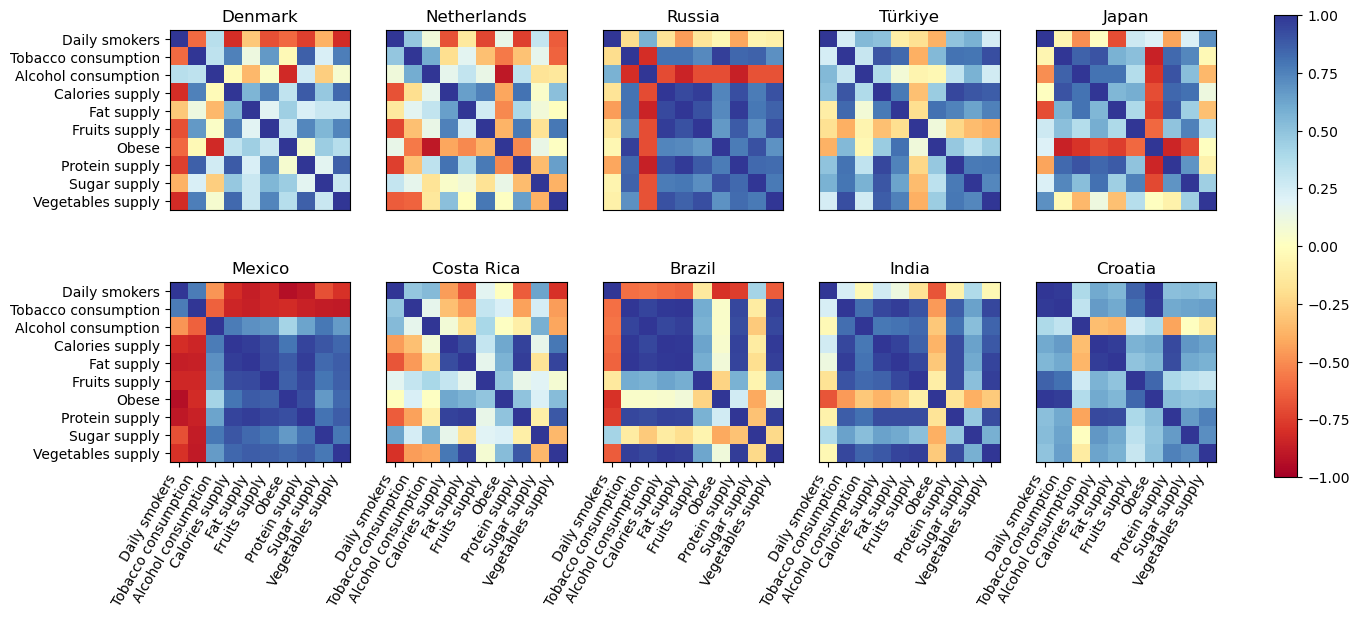

In [727]:
rows,cols=2,5
fig,ax=plt.subplots(rows,cols,figsize=(15,6))
# plt.suptitle('Correlation Matrices')

# Store the last image for colorbar
im = None 

for i,country in enumerate(countries):
    matrix = new_df.xs(country, level="country").corr()
    row,col=divmod(i,cols)
    ax[row,col].imshow(matrix, cmap='RdYlBu')
    ax[row,col].set_title(country)
    
    if row==rows-1:
        ax[row,col].set_xticks(range(len(matrix.columns)))
        ax[row,col].set_xticklabels(new_df.columns, rotation=60, ha='right')
    else:
        ax[row,col].set_xticks([])
        
    if col==0:
        ax[row,col].set_yticks(range(len(matrix.columns)))
        ax[row,col].set_yticklabels(new_df.columns)

    else:
        ax[row,col].set_yticks([])
    ax[row,col].set_title(country)
    
    # Plot correlation matrix with fixed color scale from -1 to 1
    im = ax[row,col].imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

# Add a single colorbar for the entire figure
fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.05)

plt.show()


In [728]:
# Ensure year is numeric
filtered_df=new_df.reset_index()  # Temporarily make year a column
filtered_df["year"] = pd.to_numeric(filtered_df["year"])
filtered_df.head()

measure,country,year,Daily smokers,Tobacco consumption,Alcohol consumption,Calories supply,Fat supply,Fruits supply,Obese,Protein supply,Sugar supply,Vegetables supply
0,Australia,1960,30.333333,NaN,9.3,3216.0,125.4,77.15,23.861538,112.45,47.35,67.4
1,Australia,1961,33.500000,NaN,9.4,3091.0,111.3,77.70,23.088462,104.90,56.20,61.5
2,Australia,1962,36.666667,NaN,9.5,3113.0,111.8,77.20,22.315385,107.90,54.40,61.4
3,Australia,1963,39.833333,NaN,9.8,3169.0,112.1,83.30,21.542308,109.10,54.80,60.1
4,Australia,1964,43.000000,16.7,10.1,3146.0,110.6,79.80,20.769231,110.30,56.20,61.4


In [729]:
for country in highest.index:
    high_avg_df = new_df.index
    high_avg_df = new_df.groupby(level="year").mean()

# Filter the data to only include the selected countries
high_avg_df = new_df[new_df.index.get_level_values('country').isin(highest.index)]
low_avg_df = new_df[new_df.index.get_level_values('country').isin(lowest.index)]

# Group by 'year' and calculate the mean of the 'smoking_rate' for each year across the selected countries
high_avg_df = high_avg_df.groupby('year').mean()
low_avg_df = low_avg_df.groupby('year').mean()

high_avg_df.head()

measure,Daily smokers,Tobacco consumption,Alcohol consumption,Calories supply,Fat supply,Fruits supply,Obese,Protein supply,Sugar supply,Vegetables supply
year,,,,,,,,,,
1960,17.727864,11.096212,3.533333,3174.055556,119.261111,95.316667,20.976709,92.366667,37.555556,95.750
1961,22.776797,11.236911,4.195000,2926.500000,90.950000,68.300000,18.005637,84.375000,30.950000,90.775
1962,27.307695,11.401662,4.327500,2906.000000,89.150000,71.975000,17.428742,83.700000,33.000000,93.525
1963,31.838593,11.566414,4.360000,2942.500000,92.550000,68.175000,16.851847,84.650000,34.175000,100.025
1964,36.369491,11.731166,4.555000,2936.250000,94.225000,74.825000,16.274952,83.550000,33.925000,99.375


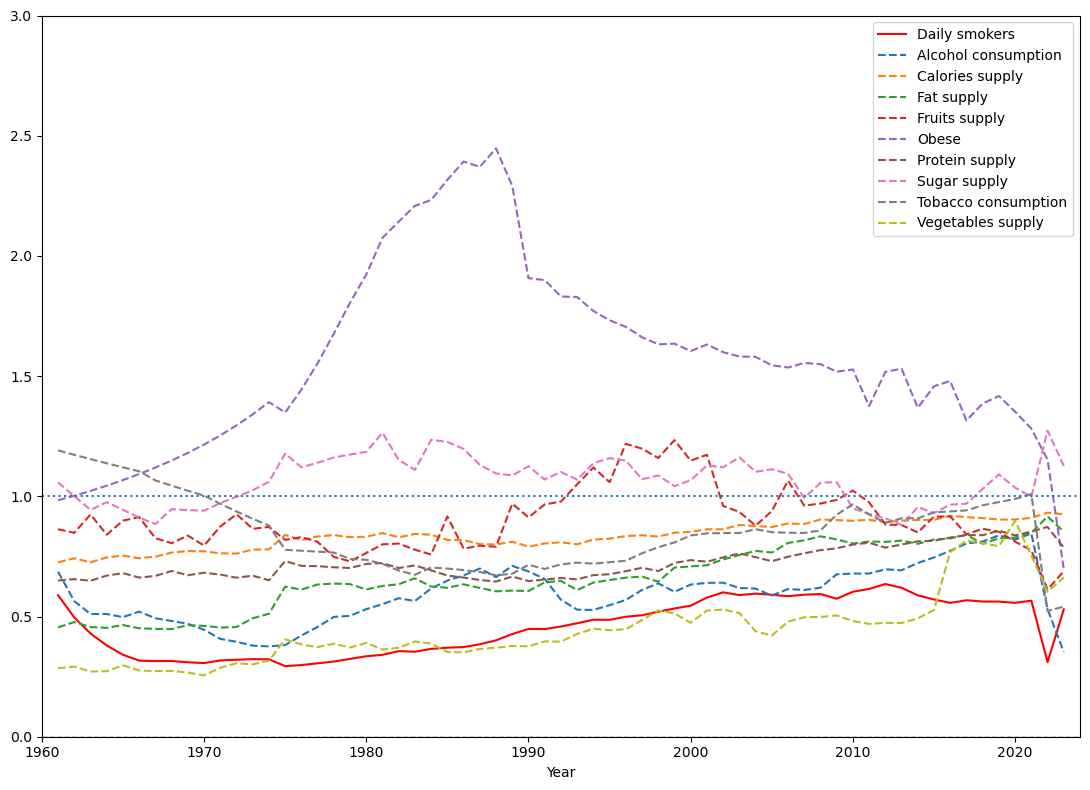

In [ ]:
plt.figure(figsize=(11, 8))
# Plot data from high_avg_df (countries with the highest smoking behavior)
plt.plot(high_avg_df.index, low_avg_df['Daily smokers']/high_avg_df['Daily smokers'], label='Daily smokers', linestyle='-', color='red')
for measure in keep_cols:
    if measure != 'Daily smokers':
        plt.plot(high_avg_df.index, low_avg_df[measure]/high_avg_df[measure], label=measure, linestyle='--')

plt.legend()
plt.axhline(0, color='black', linewidth=1, linestyle='--')
# Global x-axis label
plt.xlabel("Year")
plt.ylim(0,3)
plt.xlim(1960,2024)
plt.axhline(y = 1, linestyle = ':') 

plt.title("Measures in Low / High Smoking Countries")
plt.tight_layout() 

plt.show()

#### Global values

In [731]:
new_df.head()

measure         Daily smokers  Tobacco consumption  Alcohol consumption  \
country   year                                                            
Australia 1960      30.333333                  NaN                  9.3   
          1961      33.500000                  NaN                  9.4   
          1962      36.666667                  NaN                  9.5   
          1963      39.833333                  NaN                  9.8   
          1964      43.000000                 16.7                 10.1   

measure         Calories supply  Fat supply  Fruits supply      Obese  \
country   year                                                          
Australia 1960           3216.0       125.4          77.15  23.861538   
          1961           3091.0       111.3          77.70  23.088462   
          1962           3113.0       111.8          77.20  22.315385   
          1963           3169.0       112.1          83.30  21.542308   
          1964           3146.0       110.6          79.80  20.769231   

measure         Protein supply  Sugar supply  Vegetables supply  
country   year                                                   
Australia 1960          112.45         47.35               67.4  
          1961          104.90         56.20               61.5  
          1962          107.90         54.40               61.4  
          1963          109.10         54.80               60.1  
          1964          110.30         56.20               61.4

**avg_df**: a mean value for each measure each year

In [732]:
avg_df = new_df.groupby("year").mean()
avg_df.head()

measure,Daily smokers,Tobacco consumption,Alcohol consumption,Calories supply,Fat supply,Fruits supply,Obese,Protein supply,Sugar supply,Vegetables supply
year,,,,,,,,,,
1960,22.509530,13.599096,6.584343,3205.379902,123.248426,88.159798,19.580429,99.029379,45.060545,97.544205
1961,19.738641,13.805595,6.995492,2805.765727,85.284082,67.559651,17.930007,83.451448,36.990207,77.571656
1962,20.754326,13.925524,7.242739,2827.009408,86.766916,69.776567,17.559335,83.778783,37.337042,76.915009
1963,21.768991,14.178379,7.327627,2851.972526,89.340793,71.310838,17.156170,84.654262,37.019818,83.150108
1964,22.775162,14.355485,7.594412,2866.289532,90.073497,74.676976,16.790911,84.814100,37.530205,82.647037


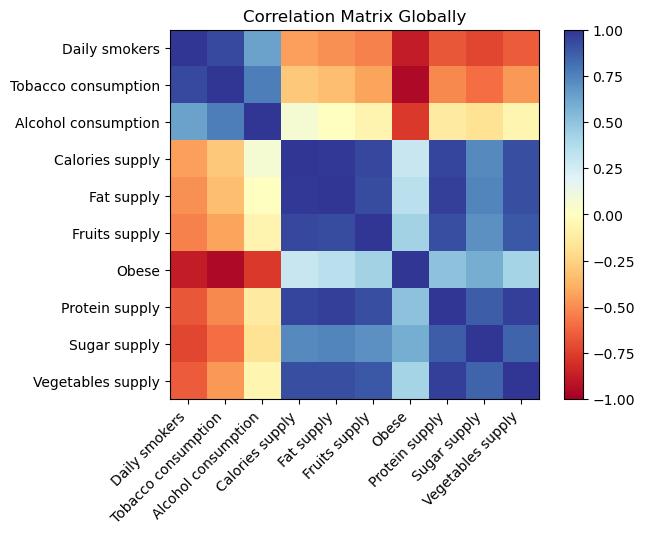

In [733]:
matrix = avg_df.corr()

# plotting correlation matrix
plt.imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

# adding colorbar
plt.colorbar()

# extracting variable names
variables = []
for i in matrix.columns:
    variables.append(i)

# Adding labels to the matrix
plt.xticks(range(len(matrix)), new_df.columns, rotation=45, ha='right')
plt.yticks(range(len(matrix)), new_df.columns)
plt.title("Correlation Matrix Globally")

# Display the plot
plt.show()


**Specific Years**

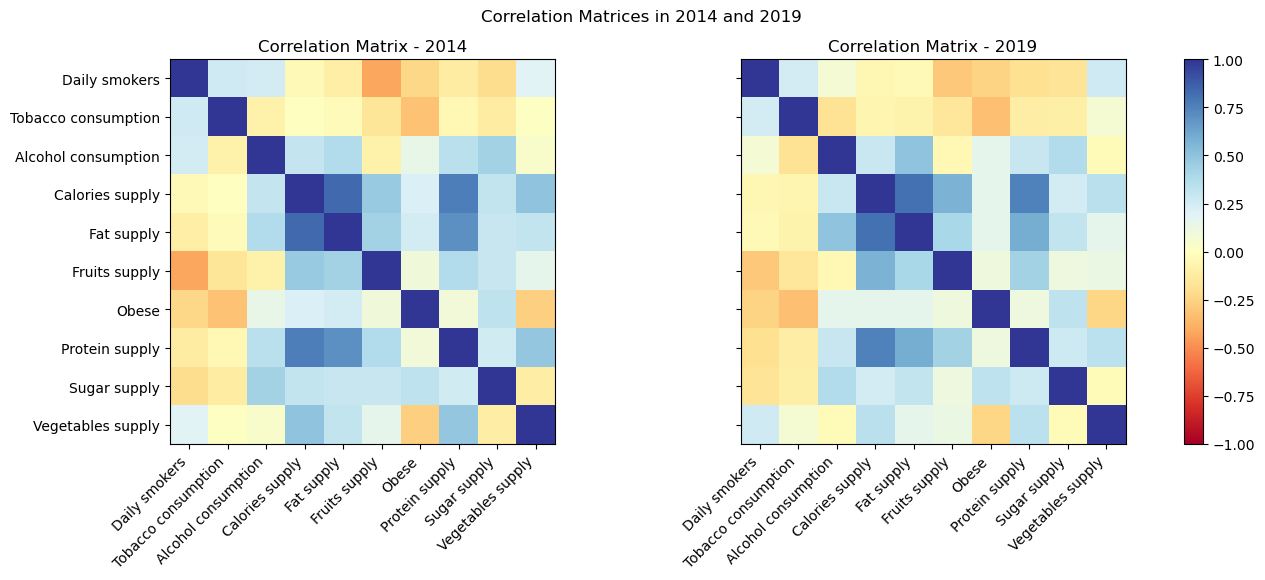

In [734]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for i, year in enumerate([2014, 2019]):
    year_df = new_df.xs(year, level="year")  # Fix indexing issue
    matrix = year_df.corr()

    # Plot correlation matrix with fixed color scale from -1 to 1
    im = ax[i].imshow(matrix, cmap='RdYlBu', vmin=-1, vmax=1)  # Set vmin and vmax

    # Extracting variable names
    variables = matrix.columns.tolist()

    # Adding labels to the matrix
    ax[i].set_xticks(range(len(variables)))
    ax[i].set_yticks(range(len(variables)))
    
    ax[i].set_xticklabels(new_df.columns, rotation=45, ha='right')
    if i ==0:
        ax[i].set_yticklabels(new_df.columns) # Only add y-labels to the first plot
    else:
        ax[i].set_yticklabels([])
    
    ax[i].set_title(f"Correlation Matrix - {year}")

# Add a single colorbar for the entire figure
fig.colorbar(im, ax=ax.ravel().tolist(), orientation='vertical', fraction=0.05, pad=0.05)

plt.suptitle("Correlation Matrices in 2014 and 2019")
plt.show()

**Plotting Significant Correlation Coefficients**

In [735]:
# for each column in the table, compute the correlation with the imd_rank
corr_list = []
for col in avg_df.drop(columns=['Daily smokers']).columns:
    corr = stats.kendalltau(new_df['Daily smokers'], new_df[col])
    corr_list.append([col, corr.correlation, corr.pvalue])

corr_df = pd.DataFrame(corr_list, columns = ['feature','correlation', 'pvalue'])

# sort the dataframe by the correlation
corr_df.sort_values(by='correlation', ascending=False, inplace=True)

corr_df.head(9)

,feature,correlation,pvalue
1,Alcohol consumption,0.145870,5.465427e-31
3,Fat supply,0.099635,2.158333e-15
2,Calories supply,0.049785,7.387829e-05
6,Protein supply,0.048999,9.641115e-05
8,Vegetables supply,0.025091,4.575285e-02
7,Sugar supply,-0.053785,1.872667e-05
4,Fruits supply,-0.089150,1.271204e-12
5,Obese,-0.227167,4.094821e-73
0,Tobacco consumption,NaN,NaN


In [736]:
corr_df.loc[:, 'adjusted_pvalues'] = fdr(corr_df['pvalue'].values)[1]
corr_df.loc[:, 'adjusted_hypothesis_test'] = fdr(corr_df['pvalue'].values)[0]  # True if the adjusted p-value is less than 0.05

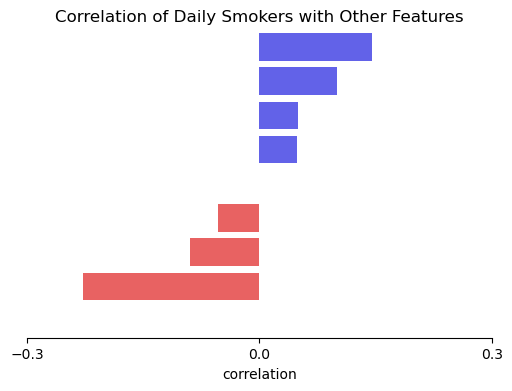

In [737]:
# Plotting the significant correlation coefficients
corr_df.loc[:, 'correlation_pvalued'] = corr_df.correlation * corr_df.adjusted_hypothesis_test.astype(int) # set to 0 if the adjusted hypothesis test is False
colors = ['red' if x < 0 else 'blue' for x in corr_df.correlation_pvalued] # red if negative correlation, blue if positive

fig, ax = plt.subplots(1, 1, figsize=(6, 4) )
sns.barplot(x='correlation_pvalued', 
            y='feature', hue='feature',
            data=corr_df, 
            palette=colors, alpha=0.7,
            ax=ax)

# We do not want any labels on the y-axis
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel('')
ax.set_xlabel('correlation')
ax.set_xticks([-0.3, 0, 0.3])
ax.set_title('Correlation of Daily Smokers with Other Features')

# No frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

### 2.2. Plotting Significant Correlation Coefficient

#### Experimenting 

In [738]:
country = 'Hungary'
corr_list = []
for col in new_df.xs(country, level='country').drop(columns=['Daily smokers']).columns:
    corr = stats.kendalltau(new_df.xs(country, level='country')['Daily smokers'], new_df.xs(country, level='country')[col])
    corr_list.append([col, corr.correlation, corr.pvalue])

corr_df = pd.DataFrame(corr_list, columns = ['feature','correlation', 'pvalue'])

# sort the dataframe by the correlation
corr_df.sort_values(by='correlation', ascending=False, inplace=True)

corr_df.head(9)

,feature,correlation,pvalue
0,Tobacco consumption,0.831754,5.843060e-22
1,Alcohol consumption,0.556692,1.574738e-10
7,Sugar supply,0.273755,1.566831e-03
6,Protein supply,0.224218,9.535024e-03
2,Calories supply,0.185689,3.176792e-02
8,Vegetables supply,0.070787,4.130143e-01
3,Fat supply,-0.033333,6.998215e-01
5,Obese,-0.097311,2.597734e-01
4,Fruits supply,-0.104156,2.285198e-01


In [739]:
corr_df.loc[:, 'adjusted_pvalues'] = fdr(corr_df['pvalue'].values)[1]
corr_df.loc[:, 'adjusted_hypothesis_test'] = fdr(corr_df['pvalue'].values)[0]  # True if the adjusted p-value is less than 0.05

In [740]:
corr_df.head(9)

,feature,correlation,pvalue,adjusted_pvalues,adjusted_hypothesis_test
0,Tobacco consumption,0.831754,5.843060e-22,5.258754e-21,True
1,Alcohol consumption,0.556692,1.574738e-10,7.086323e-10,True
7,Sugar supply,0.273755,1.566831e-03,4.700492e-03,True
6,Protein supply,0.224218,9.535024e-03,2.145380e-02,True
2,Calories supply,0.185689,3.176792e-02,5.718225e-02,False
8,Vegetables supply,0.070787,4.130143e-01,4.646410e-01,False
3,Fat supply,-0.033333,6.998215e-01,6.998215e-01,False
5,Obese,-0.097311,2.597734e-01,3.339944e-01,False
4,Fruits supply,-0.104156,2.285198e-01,3.339944e-01,False


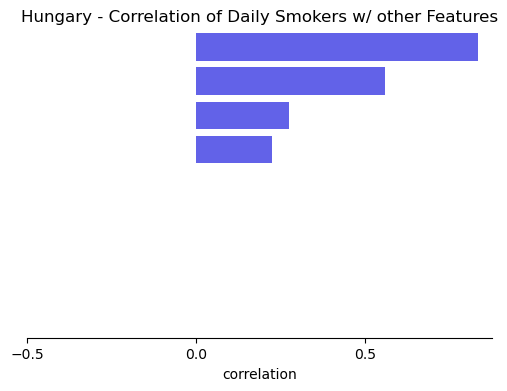

In [741]:
# Plotting the significant correlation coefficients
corr_df.loc[:, 'correlation_pvalued'] = corr_df.correlation * corr_df.adjusted_hypothesis_test.astype(int) # set to 0 if the adjusted hypothesis test is False
colors = ['red' if x < 0 else 'blue' for x in corr_df.correlation_pvalued] # red if negative correlation, blue if positive

fig, ax = plt.subplots(1, 1, figsize=(6, 4) )
sns.barplot(x='correlation_pvalued', 
            y='feature', hue='feature',
            data=corr_df, 
            palette=colors, alpha=0.7,
            ax=ax)

# We do not want any labels on the y-axis
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel('')
ax.set_xlabel('correlation')
ax.set_xticks([-0.5, 0, 0.5])
ax.set_title(country + ' - Correlation of Daily Smokers w/ other Features')

# No frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

#### Highest and Lowest Percentage of _Daily smokers_.

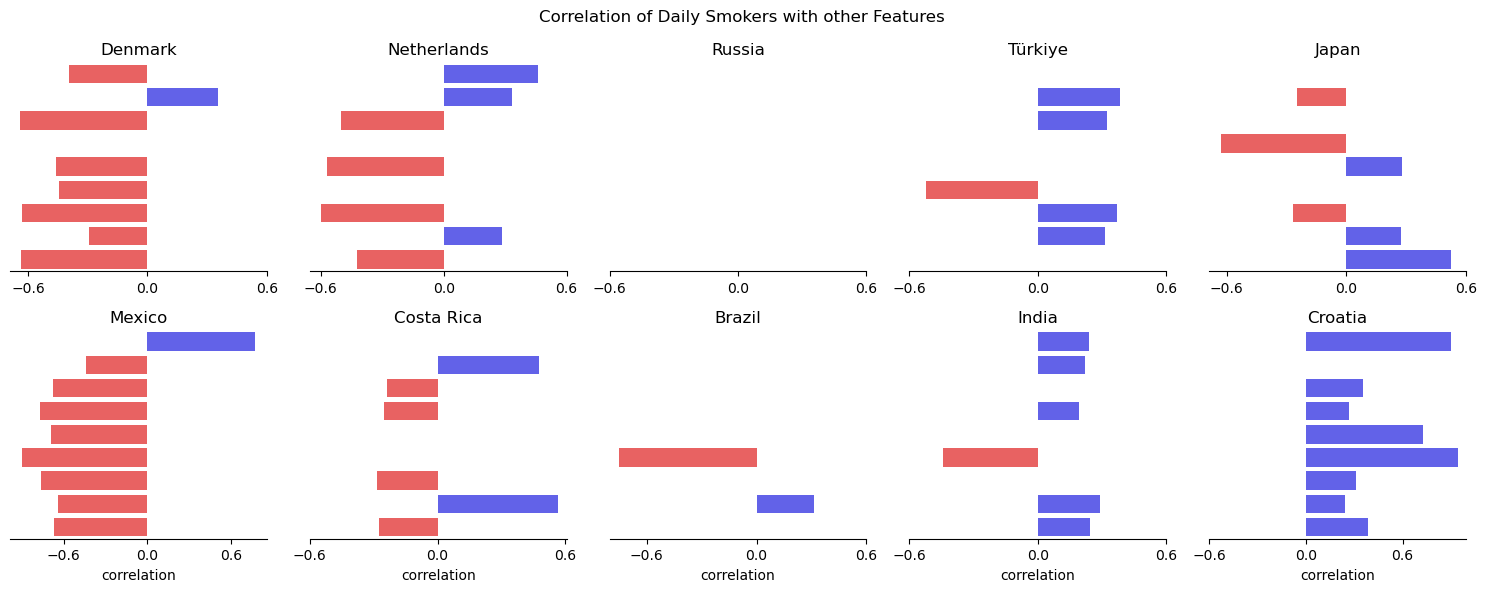

In [742]:
rows,cols=2,5
fig,ax=plt.subplots(rows,cols,figsize=(15,6))

for i,country in enumerate(countries):
    row, col = divmod(i, cols)
    
    corr_list = []
    
    for column in new_df.xs(country, level='country').drop(columns=['Daily smokers']).columns:
        corr = stats.kendalltau(new_df.xs(country, level='country')['Daily smokers'], 
                                new_df.xs(country, level='country')[column])
        corr_list.append([column, corr.correlation, corr.pvalue])

    corr_df = pd.DataFrame(corr_list, columns = ['feature','correlation', 'pvalue'])
    # corr_df.sort_values(by='correlation', ascending=False, inplace=True)
    corr_df.loc[:, 'adjusted_pvalues'] = fdr(corr_df['pvalue'].values)[1]
    corr_df.loc[:, 'adjusted_hypothesis_test'] = fdr(corr_df['pvalue'].values)[0] 
    corr_df.loc[:, 'correlation_pvalued'] = corr_df.correlation * corr_df.adjusted_hypothesis_test.astype(int) # set to 0 if the adjusted hypothesis test is False
    colors = ['red' if x < 0 else 'blue' for x in corr_df.correlation_pvalued] # red if negative correlation, blue if positive

    sns.barplot(x='correlation_pvalued', 
                y='feature', hue='feature',
                data=corr_df, 
                palette=colors, alpha=0.7,
                ax=ax[row,col])

    # We do not want any labels on the y-axis
    ax[row,col].set_yticks([])
    ax[row,col].set_yticklabels([])
    ax[row,col].set_ylabel('')
    
    if row == 0:
        ax[row,col].set_xlabel('')
    else:
        ax[row,col].set_xlabel('correlation')
    ax[row,col].set_xticks([-0.6, 0, 0.6])
    
    ax[row,col].set_title(country)

    # No frame
    ax[row,col].spines['top'].set_visible(False)
    ax[row,col].spines['right'].set_visible(False)
    ax[row,col].spines['left'].set_visible(False)

plt.suptitle('Correlation of Daily Smokers with other Features')
plt.tight_layout()
plt.show()


**Comparing the Average of High and Low Percentage Daily Smoker Countries**

In [743]:
high_avg_df.head()

measure,Daily smokers,Tobacco consumption,Alcohol consumption,Calories supply,Fat supply,Fruits supply,Obese,Protein supply,Sugar supply,Vegetables supply
year,,,,,,,,,,
1960,17.727864,11.096212,3.533333,3174.055556,119.261111,95.316667,20.976709,92.366667,37.555556,95.750
1961,22.776797,11.236911,4.195000,2926.500000,90.950000,68.300000,18.005637,84.375000,30.950000,90.775
1962,27.307695,11.401662,4.327500,2906.000000,89.150000,71.975000,17.428742,83.700000,33.000000,93.525
1963,31.838593,11.566414,4.360000,2942.500000,92.550000,68.175000,16.851847,84.650000,34.175000,100.025
1964,36.369491,11.731166,4.555000,2936.250000,94.225000,74.825000,16.274952,83.550000,33.925000,99.375


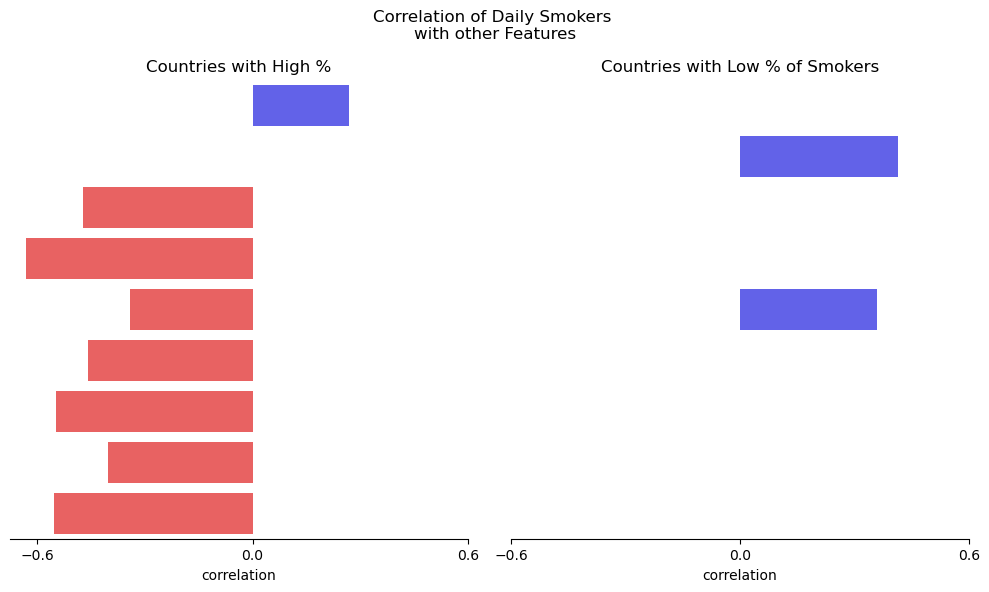

In [744]:
rows,cols=1,2
fig,ax=plt.subplots(rows,cols,figsize=(10,6))

for i,dfs in enumerate([high_avg_df,low_avg_df]):
    col = i
    
    corr_list = []
    for column in dfs.drop(columns=['Daily smokers']).columns:
        corr = stats.kendalltau(dfs['Daily smokers'], dfs[column])
        corr_list.append([column, corr.correlation, corr.pvalue])

    corr_df = pd.DataFrame(corr_list, columns=['feature', 'correlation', 'pvalue'])
    corr_df['adjusted_pvalues'] = fdr(corr_df['pvalue'].values)[1]
    corr_df['adjusted_hypothesis_test'] = fdr(corr_df['pvalue'].values)[0]
    corr_df['correlation_pvalued'] = corr_df.correlation * corr_df.adjusted_hypothesis_test.astype(int)

    colors = ['red' if x < 0 else 'blue' for x in corr_df.correlation_pvalued]

    sns.barplot(
        x='correlation_pvalued', 
        y='feature', hue='feature',
        data=corr_df, 
        palette=colors, alpha=0.7,
        ax=ax[col],
    )

    ax[col].set_yticks([])
    ax[col].set_yticklabels([])
    ax[col].set_ylabel('')
    ax[col].set_xlabel('correlation')
    ax[col].set_xticks([-0.6, 0, 0.6])
    ax[col].set_title('Countries with High %' if i == 0 else 'Countries with Low % of Smokers')
    
    # No frame
    for spine in ['top', 'right', 'left']:
        ax[col].spines[spine].set_visible(False)

plt.suptitle('Correlation of Daily Smokers \nwith other Features')
plt.tight_layout()
plt.show()

In [745]:
high_avg_df.drop(columns=['Daily smokers']).columns

Index(['Tobacco consumption', 'Alcohol consumption', 'Calories supply',
       'Fat supply', 'Fruits supply', 'Obese', 'Protein supply',
       'Sugar supply', 'Vegetables supply'],
      dtype='object', name='measure')

### Sexes Correlations 

In [746]:
df.head()

,country,year,MSR,measure,sex,age,value,method,units
0,United States,1961,FTS,Fat supply,_T,_T,110.2,_Z,Grammes per person per day
1,United States,1962,FTS,Fat supply,_T,_T,109.1,_Z,Grammes per person per day
2,United States,1963,FTS,Fat supply,_T,_T,110.7,_Z,Grammes per person per day
3,United States,1964,FTS,Fat supply,_T,_T,114.2,_Z,Grammes per person per day
4,United States,1965,FTS,Fat supply,_T,_T,113.0,_Z,Grammes per person per day


In [747]:
variable_names = ['Alcohol consumption', 
                  'Calories supply',
                  'Daily fruits',
                  'Daily smokers',
                  'Daily vegetables',
                  'Fat supply', 
                  'Fruits supply',
                  'Obese',
                  'Overweight',
                  'Overweight or obese',
                  'Protein supply',
                  'Regular vaping product users',
                  'Sugar supply',
                  'Tobacco consumption',
                  'Vegetables supply']
keep_cols = ['Alcohol consumption', 'Calories supply', 'Daily smokers', 'Fat supply',
       'Fruits supply', 'Obese', 'Protein supply', 'Sugar supply',
       'Tobacco consumption', 'Vegetables supply']

In [748]:
df_f = df[(df['age']=='_T') & (df['sex']=='F')]
df_f = df_f.drop(columns=['age','sex'])
new_f = df_f.copy()
new_f = df_f.pivot_table(
        index=["country", "year"],
        columns="measure",
        values=["value"],
        margins=False,
    )
new_f.columns = new_f.columns.droplevel(0)
new_f = new_f.apply(lambda x: x.interpolate(method='linear'))
new_f=new_f.drop(index='Argentina')
new_f=new_f[['Daily fruits','Daily smokers','Daily vegetables','Obese']]
new_f.head()

measure         Daily fruits  Daily smokers  Daily vegetables      Obese
country   year                                                          
Australia 1964           NaN           28.0               NaN  19.866667
          1966           NaN           26.0               NaN  17.433333
          1969           NaN           28.0               NaN  15.000000
          1974           NaN           29.6               NaN  12.566667
          1976           NaN           32.5               NaN  10.133333

In [749]:
df_f = df[(df['age']=='_T') & (df['sex']=='M')]
df_f = df_f.drop(columns=['age','sex'])
new_m = df_f.copy()
new_m = df_f.pivot_table(
        index=["country", "year"],
        columns="measure",
        values=["value"],
        margins=False,
    )
new_m.columns = new_m.columns.droplevel(0)
new_m = new_m.apply(lambda x: x.interpolate(method='linear'))
new_m=new_m.drop(index='Argentina')
new_m=new_m[['Daily fruits','Daily smokers','Daily vegetables','Obese']]
new_m.head()

measure         Daily fruits  Daily smokers  Daily vegetables      Obese
country   year                                                          
Australia 1964           NaN           58.0               NaN  19.266667
          1966           NaN           55.0               NaN  17.233333
          1969           NaN           45.0               NaN  15.200000
          1974           NaN           45.3               NaN  13.166667
          1976           NaN           43.9               NaN  11.133333

(0.0, 100.0)

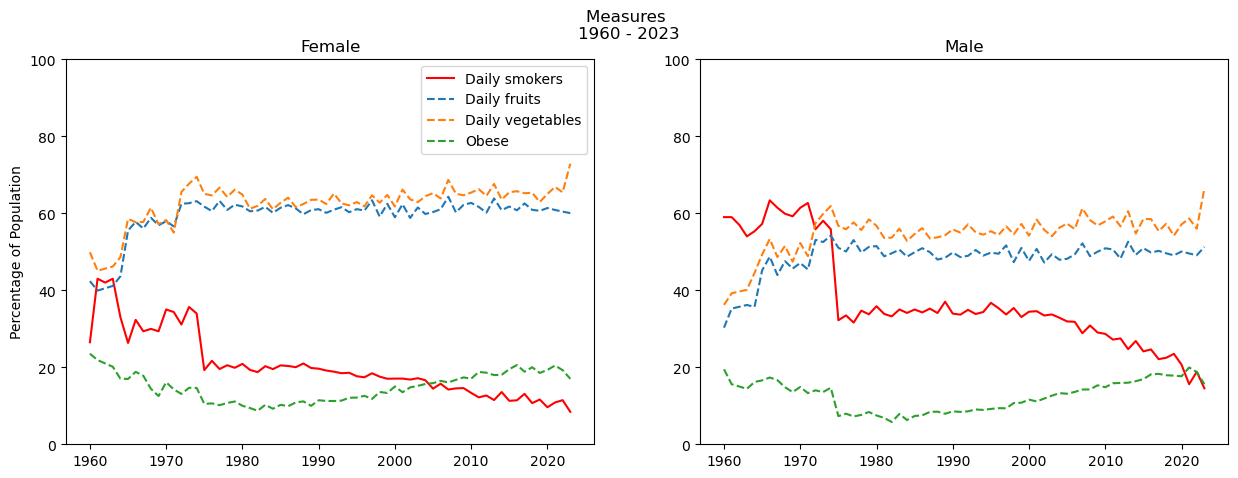

In [750]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(new_f['Daily smokers'].groupby(level='year').mean(), label='Daily smokers', color='r', linestyle='-')
ax[1].plot(new_m['Daily smokers'].groupby(level='year').mean(), color='r', linestyle='-')
for measure, color in zip(new_f.drop(columns=('Daily smokers')).columns, ('navy', 'orange', 'green')):
    ax[0].plot(new_f[measure].groupby(level='year').mean(), label=measure, linestyle='--')
    ax[1].plot(new_m[measure].groupby(level='year').mean(), linestyle='--')
ax[0].legend()
plt.suptitle('Measures \n1960 - 2023')
ax[0].set_title('Female')
ax[1].set_title('Male')
ax[0].set_ylabel('Percentage of Population')
ax[0].set_ylim(0,100)
ax[1].set_ylim(0,100)


(0.0, 5.5)

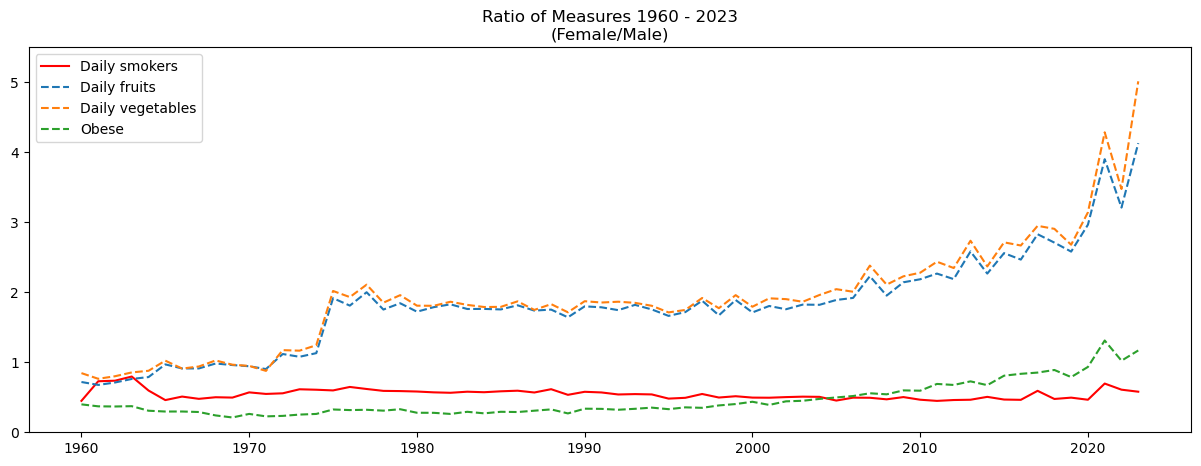

In [751]:
plt.figure( figsize=(15, 5))
plt.plot(new_f['Daily smokers'].groupby(level='year').mean()/new_m['Daily smokers'].groupby(level='year').mean(), label='Daily smokers', color='r', linestyle='-')
for measure, color in zip(new_f.drop(columns=('Daily smokers')).columns, ('navy', 'orange', 'green')):
    plt.plot((new_f[measure].groupby(level='year').mean())/(new_m['Daily smokers'].groupby(level='year').mean()), label=measure, linestyle='--')
plt.legend()
plt.title('Ratio of Measures 1960 - 2023\n(Female/Male)')
plt.ylim(0,5.5)
